# AerialPerson-YOLO26m-P2-ATTI — Final 45-Epoch Edition

**Single-model Colab notebook for high-accuracy aerial person detection and tracking**

This final edition keeps the full proposed architecture and all accuracy-oriented ideas while limiting the complete training budget to **45 epochs**:

- YOLO26m backbone initialized from pretrained weights
- official P2/P3/P4/P5 detection architecture (strides 4/8/16/32)
- official VisDrone train/validation/test separation
- person-only learning by merging `pedestrian` and `people`
- train-only person-context tiles
- three-stage progressive-resolution training
- full-frame distribution-restoration fine-tuning
- untouched full-frame test evaluation
- Adaptive Temporal Tiled Inference (ATTI)
- cross-view detection fusion
- ByteTrack after fusion
- ONNX/TensorRT export and complete-pipeline FPS reporting

The notebook trains exactly one detector and stores every persistent output in Google Drive.

## What is preserved in the 35-epoch version

The reduction in runtime is achieved only by redistributing the epoch budget. The accuracy-oriented design is not removed:

1. **P2 remains active** for very small people.
2. **Both full-frame and train-only context-tile learning remain active.**
3. **The original 960 and 1280 resolutions are preserved.**
4. **A final full-frame 1280 fine-tuning stage remains active** to reduce train/test distribution mismatch.
5. **ATTI, cross-view fusion, and ByteTrack remain available for deployment and evaluation.**
6. The full budget is fixed at **10 + 15 + 10 = 35 epochs**.


---


This is a new experiment and must not resume a checkpoint created with the older 65-epoch plan.

## 1. Install the reproducible environment

In [1]:
# Run once in a fresh Colab runtime.
# expandable_segments reduces CUDA allocator fragmentation.
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

%pip install -q -U \
  "ultralytics==8.4.114" \
  "supervision>=0.27.0" \
  "onnx>=1.16.0" \
  "onnxruntime-gpu>=1.19.0" \
  "pycocotools>=2.0.8" \
  "pandas>=2.2.0" \
  "pyyaml>=6.0.1" \
  "tabulate>=0.9.0" \
  "requests>=2.32.0" \
  "tqdm>=4.66.0"

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 148.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 8.7 MB/s eta

## 2. Imports, Google Drive, and GPU verification

In [2]:
from __future__ import annotations

import gc
import hashlib
import inspect
import json
import math
import os
import platform
import random
import shutil
import subprocess
import sys
import time
from collections import defaultdict, deque
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable, Sequence

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torchvision
import yaml
from PIL import Image
from tqdm.auto import tqdm

from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Not running in Colab; local folders will be used.")

print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required. Select an L4/A100 GPU runtime.")

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA runtime:", torch.version.cuda)
subprocess.run(["nvidia-smi"], check=False)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
GPU: NVIDIA L4
CUDA runtime: 12.8


CompletedProcess(args=['nvidia-smi'], returncode=0)

## 3. Main configuration — one model and one experiment

In [3]:
# ============================================================
# Change only these user-facing values for a new experiment.
# ============================================================

EXPERIMENT_ID = "yolo26m_p2_atti_45e_v1"
RESUME_INTERRUPTED_STAGE = True
OVERWRITE_EXPERIMENT = False
REBUILD_DATASETS = False

# Main training switch. Exactly one model is trained.
RUN_TRAINING = True

# Evaluation and export switches.
RUN_FULL_FRAME_TEST = True
RUN_TILED_COCO_TEST = True
RUN_ALL_TILE_ACCURACY_MODE = False  # expensive; set True for maximum-accuracy evaluation
EXPORT_ONNX = True
EXPORT_TENSORRT_ON_THIS_GPU = False  # build the engine on the target RTX 3070 instead

# Video demonstration switches.
DOWNLOAD_DEMO_VIDEO = True
RUN_VIDEO_TRACKING = False  # enable after training/evaluation completes
VIDEO_MODE = "balanced"     # "fast", "balanced", or "accuracy"
MAX_VIDEO_FRAMES = 600      # None processes the complete video

# Model identity.
MODEL_KEY = "aerial_yolo26m_p2_atti"
DISPLAY_NAME = "AerialPerson-YOLO26m-P2-ATTI"
PRETRAINED_WEIGHTS = "yolo26m.pt"
P2_YAML_URL = (
    "https://raw.githubusercontent.com/ultralytics/ultralytics/main/"
    "ultralytics/cfg/models/26/yolo26-p2.yaml"
)

# Person-only problem definition.
SOURCE_PERSON_CLASSES = (0, 1)  # VisDrone pedestrian + people
PERSON_CLASS_ID = 0
PERSON_CLASS_NAME = "person"

# Target deployment.
TARGET_GPU = "RTX 3070 8GB"
TARGET_MIN_PIPELINE_FPS = 10.0

print("Selected model:", DISPLAY_NAME)
print("Only this model will be trained.")

Selected model: AerialPerson-YOLO26m-P2-ATTI
Only this model will be trained.


## 4. Persistent paths and immutable configuration

In [4]:
@dataclass(frozen=True)
class ProjectConfig:
    project_name: str = "aerial_person_yolo26m_p2_atti"
    seed: int = 42
    workers: int = 4
    save_period: int = 1
    max_det: int = 1000

    # Dataset construction.
    max_context_tiles: int = 2800
    max_tiles_per_source_image: int = 2
    tiny_side_threshold_px: float = 30.0
    context_tile_min_side: int = 384
    context_tile_max_side: int = 768
    minimum_visible_fraction: float = 0.50

    # Inference.
    full_imgsz: int = 1280
    tile_imgsz: int = 960
    tile_size: int = 768
    tile_overlap: float = 0.20
    prediction_conf: float = 0.10
    metric_conf: float = 0.001
    view_nms_iou: float = 0.55

    # Balanced ATTI.
    tile_refresh_interval: int = 5
    max_balanced_tiles: int = 2
    low_conf_trigger: float = 0.30
    count_drop_ratio: float = 0.65

CFG = ProjectConfig()

if IN_COLAB:
    DRIVE_ROOT = Path("/content/drive/MyDrive") / CFG.project_name
    LOCAL_ROOT = Path("/content") / CFG.project_name
else:
    DRIVE_ROOT = Path.cwd() / f"{CFG.project_name}_drive"
    LOCAL_ROOT = Path.cwd() / f"{CFG.project_name}_local"

CONFIG_ROOT = DRIVE_ROOT / "configs"
DATASETS_ROOT = LOCAL_ROOT / "datasets"
FULL_DATASET_ROOT = DATASETS_ROOT / "visdrone_person_full"
HYBRID_DATASET_ROOT = DATASETS_ROOT / "visdrone_person_hybrid"
EXPERIMENT_ROOT = DRIVE_ROOT / "runs" / MODEL_KEY / EXPERIMENT_ID
REPORTS_ROOT = EXPERIMENT_ROOT / "reports"
EXPORTS_ROOT = EXPERIMENT_ROOT / "exports"
TRACKING_ROOT = EXPERIMENT_ROOT / "tracking"
DELIVERY_ROOT = EXPERIMENT_ROOT / "delivery"

if OVERWRITE_EXPERIMENT and EXPERIMENT_ROOT.exists():
    print("Deleting selected experiment:", EXPERIMENT_ROOT)
    shutil.rmtree(EXPERIMENT_ROOT)

for folder in [
    DRIVE_ROOT, LOCAL_ROOT, CONFIG_ROOT, DATASETS_ROOT,
    FULL_DATASET_ROOT, HYBRID_DATASET_ROOT,
    EXPERIMENT_ROOT, REPORTS_ROOT, EXPORTS_ROOT,
    TRACKING_ROOT, DELIVERY_ROOT,
]:
    folder.mkdir(parents=True, exist_ok=True)

P2_MODEL_YAML = CONFIG_ROOT / "yolo26m-p2.yaml"
FULL_DATA_YAML = FULL_DATASET_ROOT / "data.yaml"
HYBRID_DATA_YAML = HYBRID_DATASET_ROOT / "data.yaml"
SNAPSHOT_PATH = EXPERIMENT_ROOT / "experiment_config.json"

snapshot = {
    "display_name": DISPLAY_NAME,
    "model_key": MODEL_KEY,
    "experiment_id": EXPERIMENT_ID,
    "pretrained_weights": PRETRAINED_WEIGHTS,
    "p2_yaml_url": P2_YAML_URL,
    "project_config": asdict(CFG),
    "source_person_classes": list(SOURCE_PERSON_CLASSES),
    "resume_interrupted_stage": RESUME_INTERRUPTED_STAGE,
    "created_at_unix": time.time(),
}

if SNAPSHOT_PATH.exists() and not RESUME_INTERRUPTED_STAGE:
    old = json.loads(SNAPSHOT_PATH.read_text(encoding="utf-8"))
    if old.get("model_key") != MODEL_KEY:
        raise RuntimeError("The experiment directory belongs to another model.")
else:
    SNAPSHOT_PATH.write_text(json.dumps(snapshot, indent=2), encoding="utf-8")

print("Persistent experiment root:", EXPERIMENT_ROOT)
print("Local dataset root:", DATASETS_ROOT)

Persistent experiment root: /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1
Local dataset root: /content/aerial_person_yolo26m_p2_atti/datasets


## 5. Reproducibility and memory helpers

In [5]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True


def clear_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        while chunk := stream.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


seed_everything(CFG.seed)
clear_memory()

## 6. Download the official VisDrone detection dataset

In [6]:
visdrone_info = check_det_dataset("VisDrone.yaml", autodownload=True)

print(json.dumps({
    key: str(value)
    for key, value in visdrone_info.items()
    if key in {"path", "train", "val", "test", "names", "nc"}
}, indent=2, default=str))


WARNING ⚠️ Dataset 'VisDrone.yaml' images not found, missing path '/content/datasets/VisDrone/images/val'
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-val.zip to /content/datasets/VisDrone/VisDrone2019-DET-val...: 100% ━━━━━━━━━━━━ 1099/1099 1.3Kfiles/s 0.8s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-test-dev.zip to /content/datasets/VisDrone/VisDrone2019-DET-test-dev...: 100% ━━━━━━━━━━━━ 3223/3223 1.3Kfiles/s 2.6s
Unzipping /content/datasets/VisDrone/VisDrone2019-DET-train.zip to /content/datasets/VisDrone/VisDrone2019-DET-train...: 100% ━━━━━━━━━━━━ 12945/12945 1.8Kfiles/s 7.1s
Converting train: ━━━━━━━━━━━━ 6471 2.4Kit/s 2.7s
Converting val: ━━━━━━━━━━━━ 548 1.4Kit/s 0.3s
Converting test: ━━━━━━━━━━━━ 1610 2.3Kit/s 0.6s
Dataset download success ✅ (17.2s), saved to /content/datasets

{
  "path": "/content/datasets/VisDrone",
  "train": "/content/datasets/VisDrone/images/train",
  "val": "/content/datasets/VisDrone/images/val",
  "test": "/content/datasets/VisDro

## 7. Dataset conversion helpers

In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def expand_image_source(source: Any) -> list[Path]:
    if source is None:
        return []
    if isinstance(source, (list, tuple)):
        output: list[Path] = []
        for item in source:
            output.extend(expand_image_source(item))
        return sorted(set(output))

    path = Path(str(source))
    if path.is_dir():
        return sorted(
            p.resolve() for p in path.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )
    if path.is_file() and path.suffix.lower() == ".txt":
        output: list[Path] = []
        for line in path.read_text(encoding="utf-8").splitlines():
            line = line.strip()
            if not line:
                continue
            candidate = Path(line)
            if not candidate.is_absolute():
                candidate = path.parent / candidate
            if candidate.suffix.lower() in IMAGE_EXTENSIONS:
                output.append(candidate.resolve())
        return sorted(set(output))
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
        return [path.resolve()]
    raise FileNotFoundError(f"Cannot expand image source: {source}")


def image_to_label_path(image_path: Path) -> Path:
    parts = list(image_path.parts)
    try:
        idx = len(parts) - 1 - parts[::-1].index("images")
        parts[idx] = "labels"
        return Path(*parts).with_suffix(".txt")
    except ValueError:
        return image_path.with_suffix(".txt")


def stable_stem(path: Path) -> str:
    digest = hashlib.sha1(str(path).encode("utf-8")).hexdigest()[:10]
    return f"{digest}_{path.stem}"


def link_or_copy(source: Path, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() or destination.is_symlink():
        destination.unlink()
    try:
        destination.symlink_to(source.resolve())
    except OSError:
        shutil.copy2(source, destination)


def read_merged_person_boxes(label_path: Path) -> list[tuple[float, float, float, float]]:
    boxes: list[tuple[float, float, float, float]] = []
    if not label_path.exists():
        return boxes

    for raw in label_path.read_text(encoding="utf-8").splitlines():
        fields = raw.strip().split()
        if len(fields) < 5:
            continue
        try:
            class_id = int(float(fields[0]))
            x, y, w, h = map(float, fields[1:5])
        except ValueError:
            continue
        if class_id not in SOURCE_PERSON_CLASSES:
            continue
        if not all(np.isfinite([x, y, w, h])):
            continue
        x = float(np.clip(x, 0.0, 1.0))
        y = float(np.clip(y, 0.0, 1.0))
        w = float(np.clip(w, 0.0, 1.0))
        h = float(np.clip(h, 0.0, 1.0))
        if w <= 0 or h <= 0:
            continue
        boxes.append((x, y, w, h))
    return boxes


def write_person_label(path: Path, boxes: Sequence[tuple[float, float, float, float]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    unique: dict[tuple[float, float, float, float], str] = {}
    for x, y, w, h in boxes:
        key = tuple(round(float(v), 7) for v in (x, y, w, h))
        unique[key] = f"0 {x:.7f} {y:.7f} {w:.7f} {h:.7f}"
    text = "\n".join(unique.values())
    path.write_text(text + ("\n" if text else ""), encoding="utf-8")


def write_data_yaml(root: Path) -> Path:
    payload = {
        "path": str(root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {0: PERSON_CLASS_NAME},
        "nc": 1,
    }
    output = root / "data.yaml"
    output.write_text(yaml.safe_dump(payload, sort_keys=False), encoding="utf-8")
    return output

## 8. Build the untouched full-frame dataset and the train-only hybrid dataset

In [8]:
def build_full_frame_dataset() -> pd.DataFrame:
    marker = FULL_DATASET_ROOT / ".complete.json"
    manifest_path = FULL_DATASET_ROOT / "manifest.csv"

    if marker.exists() and manifest_path.exists() and not REBUILD_DATASETS:
        print("Using existing full-frame dataset.")
        return pd.read_csv(manifest_path)

    if FULL_DATASET_ROOT.exists():
        shutil.rmtree(FULL_DATASET_ROOT)
    FULL_DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    rows: list[dict[str, Any]] = []
    split_map = {
        "train": expand_image_source(visdrone_info.get("train")),
        "val": expand_image_source(visdrone_info.get("val")),
        "test": expand_image_source(visdrone_info.get("test")),
    }

    for split, images in split_map.items():
        image_dir = FULL_DATASET_ROOT / "images" / split
        label_dir = FULL_DATASET_ROOT / "labels" / split
        image_dir.mkdir(parents=True, exist_ok=True)
        label_dir.mkdir(parents=True, exist_ok=True)

        for source_image in tqdm(images, desc=f"Converting {split}"):
            source_label = image_to_label_path(source_image)
            stem = stable_stem(source_image)
            destination_image = image_dir / f"{stem}{source_image.suffix.lower()}"
            destination_label = label_dir / f"{stem}.txt"

            link_or_copy(source_image, destination_image)
            boxes = read_merged_person_boxes(source_label)
            write_person_label(destination_label, boxes)

            rows.append({
                "split": split,
                "augmentation": "full_frame",
                "source_image": str(source_image),
                "source_label": str(source_label),
                "output_image": str(destination_image),
                "output_label": str(destination_label),
                "person_count": len(boxes),
            })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    write_data_yaml(FULL_DATASET_ROOT)
    marker.write_text(json.dumps({"rows": len(manifest)}, indent=2), encoding="utf-8")
    return manifest


def box_xywhn_to_xyxy(box: tuple[float, float, float, float], width: int, height: int) -> np.ndarray:
    x, y, w, h = box
    return np.array([
        (x - w / 2) * width,
        (y - h / 2) * height,
        (x + w / 2) * width,
        (y + h / 2) * height,
    ], dtype=np.float32)


def create_context_tile(
    image_path: Path,
    label_path: Path,
    target_index: int,
    output_image: Path,
    output_label: Path,
    rng: np.random.Generator,
) -> bool:
    image = cv2.imread(str(image_path))
    if image is None:
        return False
    height, width = image.shape[:2]
    boxes = read_merged_person_boxes(label_path)
    if not boxes or target_index >= len(boxes):
        return False

    pixel_boxes = [box_xywhn_to_xyxy(box, width, height) for box in boxes]
    target = pixel_boxes[target_index]
    target_w = max(float(target[2] - target[0]), 1.0)
    target_h = max(float(target[3] - target[1]), 1.0)
    target_side = max(target_w, target_h)

    desired_side = int(np.clip(target_side * rng.uniform(12.0, 18.0),
                               CFG.context_tile_min_side,
                               CFG.context_tile_max_side))
    desired_side = min(desired_side, width, height)
    if desired_side < 64:
        return False

    center_x = float((target[0] + target[2]) / 2)
    center_y = float((target[1] + target[3]) / 2)
    jitter = 0.12 * desired_side
    center_x += float(rng.uniform(-jitter, jitter))
    center_y += float(rng.uniform(-jitter, jitter))

    x0 = int(np.clip(round(center_x - desired_side / 2), 0, max(width - desired_side, 0)))
    y0 = int(np.clip(round(center_y - desired_side / 2), 0, max(height - desired_side, 0)))
    x1 = x0 + desired_side
    y1 = y0 + desired_side

    crop = image[y0:y1, x0:x1]
    if crop.size == 0:
        return False

    crop_boxes: list[tuple[float, float, float, float]] = []
    for box in pixel_boxes:
        ix1 = max(float(box[0]), x0)
        iy1 = max(float(box[1]), y0)
        ix2 = min(float(box[2]), x1)
        iy2 = min(float(box[3]), y1)
        intersection = max(ix2 - ix1, 0.0) * max(iy2 - iy1, 0.0)
        original_area = max(float(box[2] - box[0]), 0.0) * max(float(box[3] - box[1]), 0.0)
        if original_area <= 0 or intersection / original_area < CFG.minimum_visible_fraction:
            continue

        cx = ((ix1 + ix2) / 2 - x0) / desired_side
        cy = ((iy1 + iy2) / 2 - y0) / desired_side
        bw = (ix2 - ix1) / desired_side
        bh = (iy2 - iy1) / desired_side
        if bw > 0 and bh > 0:
            crop_boxes.append((cx, cy, bw, bh))

    if not crop_boxes:
        return False

    output_image.parent.mkdir(parents=True, exist_ok=True)
    output_label.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_image), crop, [cv2.IMWRITE_JPEG_QUALITY, 95])
    write_person_label(output_label, crop_boxes)
    return True


def build_hybrid_dataset(full_manifest: pd.DataFrame) -> pd.DataFrame:
    marker = HYBRID_DATASET_ROOT / ".complete.json"
    manifest_path = HYBRID_DATASET_ROOT / "manifest.csv"

    if marker.exists() and manifest_path.exists() and not REBUILD_DATASETS:
        print("Using existing hybrid dataset.")
        return pd.read_csv(manifest_path)

    if HYBRID_DATASET_ROOT.exists():
        shutil.rmtree(HYBRID_DATASET_ROOT)
    HYBRID_DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    rows: list[dict[str, Any]] = []

    # Copy/link every full-frame sample. Val and test remain full-frame only.
    for record in tqdm(full_manifest.to_dict("records"), desc="Linking full frames"):
        split = record["split"]
        source_image = Path(record["output_image"])
        source_label = Path(record["output_label"])
        destination_image = HYBRID_DATASET_ROOT / "images" / split / source_image.name
        destination_label = HYBRID_DATASET_ROOT / "labels" / split / source_label.name
        link_or_copy(source_image, destination_image)
        link_or_copy(source_label, destination_label)
        rows.append({**record, "output_image": str(destination_image), "output_label": str(destination_label)})

    # Candidate tiny persons are selected from train only.
    train_rows = [r for r in rows if r["split"] == "train" and r["augmentation"] == "full_frame"]
    candidates: list[tuple[float, dict[str, Any], int]] = []
    for record in tqdm(train_rows, desc="Finding tiny-person candidates"):
        image_path = Path(record["output_image"])
        label_path = Path(record["output_label"])
        with Image.open(image_path) as image:
            width, height = image.size
        boxes = read_merged_person_boxes(label_path)
        tiny_indices: list[tuple[float, int]] = []
        for index, (_, _, w, h) in enumerate(boxes):
            side_px = max(w * width, h * height)
            if side_px <= CFG.tiny_side_threshold_px:
                tiny_indices.append((side_px, index))
        tiny_indices.sort(key=lambda item: item[0])
        for side_px, index in tiny_indices[:CFG.max_tiles_per_source_image]:
            candidates.append((side_px, record, index))

    rng = np.random.default_rng(CFG.seed)
    # Keep strong emphasis on tiny targets while avoiding deterministic image ordering.
    candidates.sort(key=lambda item: item[0])
    bands = np.array_split(np.array(candidates, dtype=object), 8) if candidates else []
    ordered_candidates: list[tuple[float, dict[str, Any], int]] = []
    for band in bands:
        band_list = list(band)
        rng.shuffle(band_list)
        ordered_candidates.extend(band_list)

    generated = 0
    for _, record, target_index in tqdm(ordered_candidates, desc="Generating ATPC tiles"):
        if generated >= CFG.max_context_tiles:
            break
        source_image = Path(record["output_image"])
        source_label = Path(record["output_label"])
        tile_stem = f"atpc_{generated:05d}_{source_image.stem}"
        output_image = HYBRID_DATASET_ROOT / "images" / "train" / f"{tile_stem}.jpg"
        output_label = HYBRID_DATASET_ROOT / "labels" / "train" / f"{tile_stem}.txt"

        if create_context_tile(
            source_image, source_label, int(target_index),
            output_image, output_label, rng,
        ):
            boxes = read_merged_person_boxes(output_label)
            rows.append({
                "split": "train",
                "augmentation": "context_tile",
                "source_image": record["source_image"],
                "source_label": record["source_label"],
                "output_image": str(output_image),
                "output_label": str(output_label),
                "person_count": len(boxes),
            })
            generated += 1

    manifest = pd.DataFrame(rows)
    manifest.to_csv(manifest_path, index=False)
    write_data_yaml(HYBRID_DATASET_ROOT)
    marker.write_text(json.dumps({"rows": len(manifest), "tiles": generated}, indent=2), encoding="utf-8")
    print("Generated context tiles:", generated)
    return manifest


FULL_MANIFEST = build_full_frame_dataset()
HYBRID_MANIFEST = build_hybrid_dataset(FULL_MANIFEST)

print("\nFull-frame dataset:")
display(FULL_MANIFEST.groupby(["split", "augmentation"]).size().rename("images").reset_index())
print("\nHybrid dataset:")
display(HYBRID_MANIFEST.groupby(["split", "augmentation"]).size().rename("images").reset_index())

Converting train:   0%|          | 0/6471 [00:00<?, ?it/s]

Converting val:   0%|          | 0/548 [00:00<?, ?it/s]

Converting test:   0%|          | 0/1610 [00:00<?, ?it/s]

Linking full frames:   0%|          | 0/8629 [00:00<?, ?it/s]

Finding tiny-person candidates:   0%|          | 0/6471 [00:00<?, ?it/s]

Generating ATPC tiles:   0%|          | 0/9422 [00:00<?, ?it/s]

Generated context tiles: 2800

Full-frame dataset:


,split,augmentation,images
0,test,full_frame,1610
1,train,full_frame,6471
2,val,full_frame,548



Hybrid dataset:


,split,augmentation,images
0,test,full_frame,1610
1,train,context_tile,2800
2,train,full_frame,6471
3,val,full_frame,548


## 9. Dataset integrity and leakage gates

In [9]:
def audit_dataset(manifest: pd.DataFrame, root: Path) -> pd.DataFrame:
    issues: list[dict[str, Any]] = []
    for record in tqdm(manifest.to_dict("records"), desc=f"Auditing {root.name}"):
        image_path = Path(record["output_image"])
        label_path = Path(record["output_label"])
        if not image_path.exists():
            issues.append({"path": str(image_path), "issue": "missing image"})
            continue
        if not label_path.exists():
            issues.append({"path": str(label_path), "issue": "missing label"})
            continue
        for line_number, raw in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
            fields = raw.split()
            if len(fields) != 5:
                issues.append({"path": str(label_path), "issue": f"line {line_number}: field count"})
                continue
            values = list(map(float, fields))
            if int(values[0]) != 0:
                issues.append({"path": str(label_path), "issue": f"line {line_number}: class is not 0"})
            if not all(np.isfinite(values)):
                issues.append({"path": str(label_path), "issue": f"line {line_number}: non-finite"})
            if not all(0.0 <= value <= 1.0 for value in values[1:]):
                issues.append({"path": str(label_path), "issue": f"line {line_number}: out of range"})
    return pd.DataFrame(issues)


# Check original-source separation using full-frame records only.
full_records = FULL_MANIFEST[FULL_MANIFEST["augmentation"] == "full_frame"]
source_sets = {
    split: set(full_records.loc[full_records["split"] == split, "source_image"].astype(str))
    for split in ["train", "val", "test"]
}

assert not (source_sets["train"] & source_sets["val"]), "Train/val leakage detected"
assert not (source_sets["train"] & source_sets["test"]), "Train/test leakage detected"
assert not (source_sets["val"] & source_sets["test"]), "Val/test leakage detected"

assert set(HYBRID_MANIFEST.loc[HYBRID_MANIFEST["augmentation"] == "context_tile", "split"]) <= {"train"}

full_issues = audit_dataset(FULL_MANIFEST, FULL_DATASET_ROOT)
hybrid_issues = audit_dataset(HYBRID_MANIFEST, HYBRID_DATASET_ROOT)

print("Full-frame issues:", len(full_issues))
print("Hybrid issues:", len(hybrid_issues))
if len(full_issues):
    display(full_issues.head(20))
if len(hybrid_issues):
    display(hybrid_issues.head(20))

assert len(full_issues) == 0
assert len(hybrid_issues) == 0
print("PASS: labels are valid and official splits do not overlap.")

Auditing visdrone_person_full:   0%|          | 0/8629 [00:00<?, ?it/s]

Auditing visdrone_person_hybrid:   0%|          | 0/11429 [00:00<?, ?it/s]

Full-frame issues: 0
Hybrid issues: 0
PASS: labels are valid and official splits do not overlap.


## 10. Visual inspection of full frames and training-only context tiles

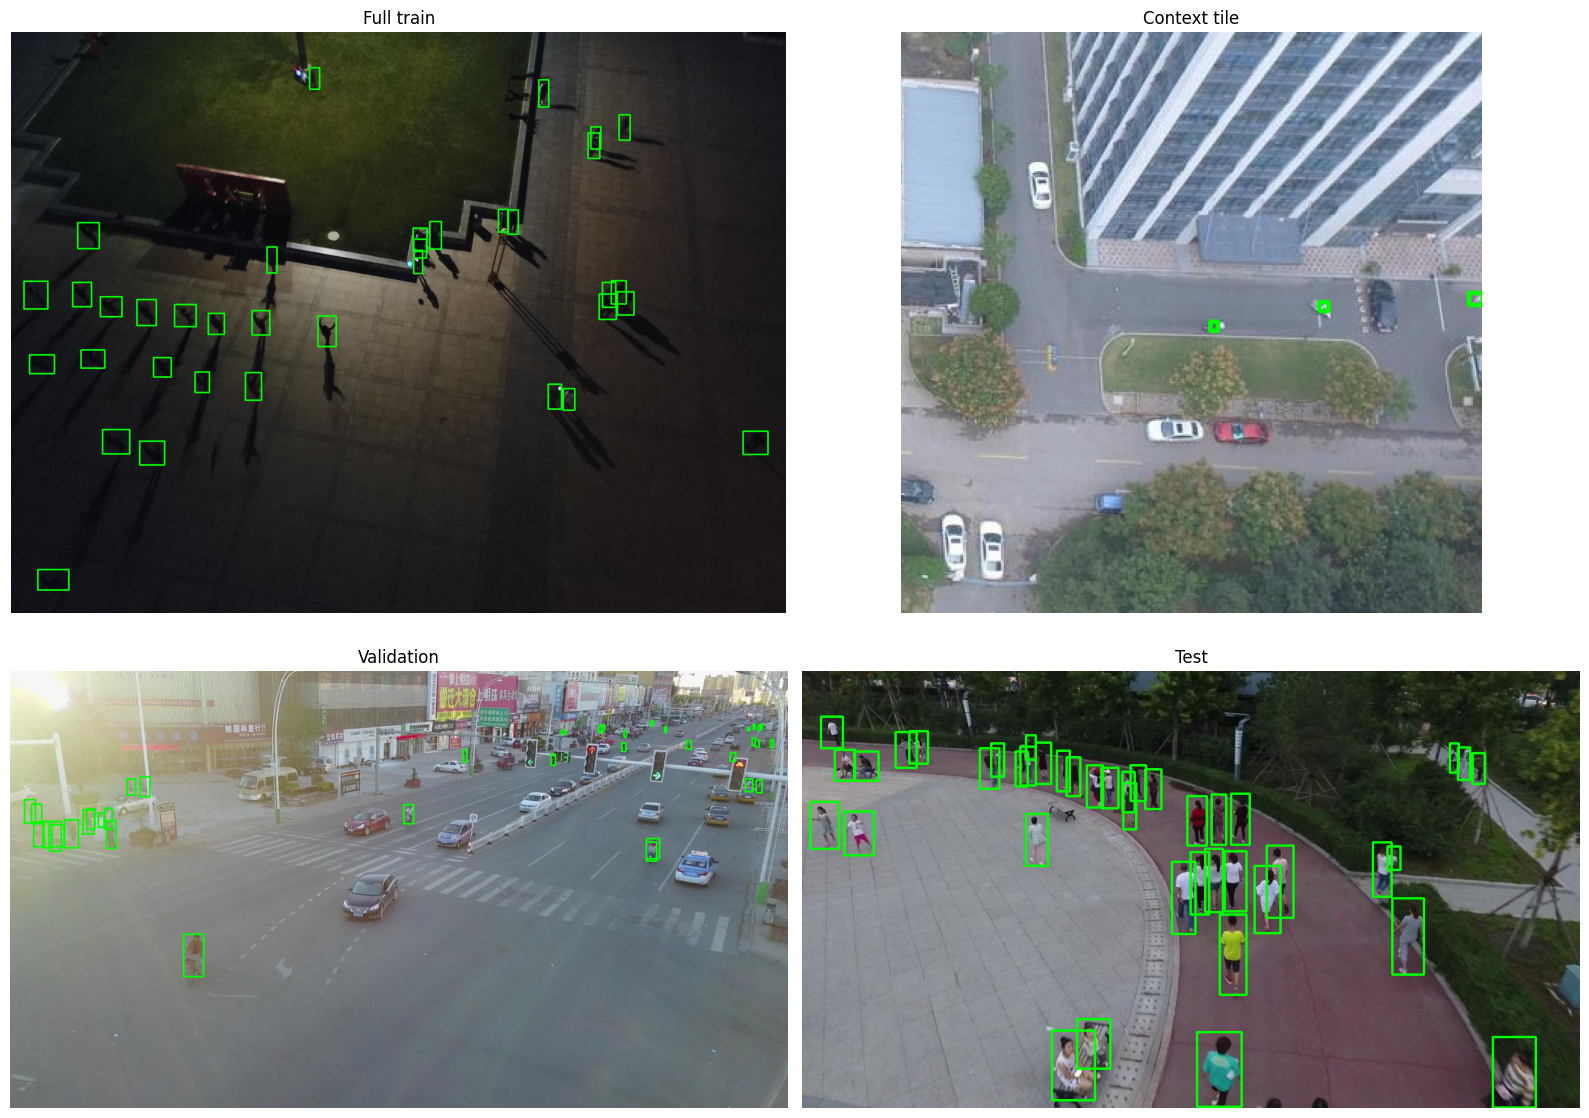

In [10]:
def draw_yolo_labels(image_path: Path, label_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    height, width = image.shape[:2]
    for x, y, w, h in read_merged_person_boxes(label_path):
        x1 = int((x - w / 2) * width)
        y1 = int((y - h / 2) * height)
        x2 = int((x + w / 2) * width)
        y2 = int((y + h / 2) * height)
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


sample_groups = [
    ("Full train", HYBRID_MANIFEST[(HYBRID_MANIFEST.split == "train") & (HYBRID_MANIFEST.augmentation == "full_frame")]),
    ("Context tile", HYBRID_MANIFEST[HYBRID_MANIFEST.augmentation == "context_tile"]),
    ("Validation", HYBRID_MANIFEST[HYBRID_MANIFEST.split == "val"]),
    ("Test", HYBRID_MANIFEST[HYBRID_MANIFEST.split == "test"]),
]

plt.figure(figsize=(16, 12))
plot_index = 1
for title, group in sample_groups:
    if len(group) == 0:
        continue
    record = group.sample(1, random_state=CFG.seed).iloc[0]
    plt.subplot(2, 2, plot_index)
    plt.imshow(draw_yolo_labels(Path(record.output_image), Path(record.output_label)))
    plt.title(title)
    plt.axis("off")
    plot_index += 1
plt.tight_layout()
plt.show()

## 11. Download the official P2 architecture and initialize YOLO26m-P2

In [11]:
def download_text(url: str, destination: Path) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    destination.write_text(response.text, encoding="utf-8")
    return destination


if not P2_MODEL_YAML.exists():
    download_text(P2_YAML_URL, P2_MODEL_YAML)

print("P2 architecture YAML:", P2_MODEL_YAML)
print(P2_MODEL_YAML.read_text(encoding="utf-8")[:600])


def build_pretrained_p2_model() -> YOLO:
    model = YOLO(str(P2_MODEL_YAML))
    model.load(PRETRAINED_WEIGHTS)
    return model


inspection_model = build_pretrained_p2_model()
inspection_model.info(detailed=False, verbose=True)

detect_modules = [
    module for module in inspection_model.model.modules()
    if module.__class__.__name__ == "Detect"
]
if not detect_modules:
    raise RuntimeError("Detect head was not found.")

strides = [int(value) for value in detect_modules[-1].stride.detach().cpu().tolist()]
print("Detection strides:", strides)
assert strides == [4, 8, 16, 32], f"Expected P2/P3/P4/P5 strides, got {strides}"

clear_memory()
del inspection_model
print("PASS: official P2/P3/P4/P5 architecture is active.")

P2 architecture YAML: /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/configs/yolo26m-p2.yaml
# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Ultralytics YOLO26 object detection model with P2/4 - P5/32 outputs
# Model docs: https://docs.ultralytics.com/models/yolo26
# Task docs: https://docs.ultralytics.com/tasks/detect

# Parameters
nc: 80 # number of classes
end2end: True # whether to use end-to-end mode
reg_max: 1 # DFL bins
scales: # model compound scaling constants, i.e. 'model=yolo26n-p2.yaml' will call yolo26-p2.yaml with scale 'n'
  # [depth, width, max_channels]
  n: [0.50, 0.25, 1024] # summary: 329 layers, 2,662,400 parameters, 2,662,400 gradients, 9.5 
Transferred 420/962 items from pretrained weights
YOLO26m-p2 summary: 349 layers, 21,144,288 parameters, 21,144,288 gradients, 91.6 GFLOPs
Detection strides: [4, 8, 16, 32]
PASS: official P2/P3/P4/P5 architecture is active.


## 12. Accuracy-oriented three-stage plan with a strict 45-epoch budget

The resolutions and all major ideas are preserved. Epochs are concentrated in the two 1280-pixel stages because small-person learning and final full-frame localization benefit most from high-resolution optimization.

| Stage | Dataset | Resolution | Epochs | Main role |
|---|---|---:|---:|---|
| 1 | Full-frame train | 960 | 12 | initialize the new P2 branch and learn scene context |
| 2 | Full-frame + train-only context tiles | 1280 | 21 | strengthen tiny-person features |
| 3 | Full-frame train | 1280 | 12 | restore test-like distribution and refine localization |
| **Total** | — | — | **45** | strict maximum budget |

The test split is never used for training, augmentation, model selection, or threshold tuning.

In [12]:
TRAINING_STAGES: list[dict[str, Any]] = [
    {
        "name": "stage1_full_960",
        "data": str(FULL_DATA_YAML),
        "epochs": 10,
        "imgsz": 960,
        "batch": 2,
        "lr0": 7.0e-4,
        "warmup_epochs": 1.0,
        "mosaic": 1.0,
        "close_mosaic": 3,
        "mixup": 0.05,
        "degrees": 5.0,
        "translate": 0.10,
        "scale": 0.45,
        "shear": 1.0,
        "fliplr": 0.50,
        "flipud": 0.10,
        "hsv_h": 0.015,
        "hsv_s": 0.45,
        "hsv_v": 0.35,
        "patience": 7,
        "purpose": (
            "Initialize the new P2 branch from compatible YOLO26m pretrained "
            "weights while learning full-scene aerial context."
        ),
    },
    {
        "name": "stage2_hybrid_1280",
        "data": str(HYBRID_DATA_YAML),
        "epochs": 15,
        "imgsz": 1280,
        "batch": 1,
        "lr0": 2.5e-4,
        "warmup_epochs": 0.75,
        "mosaic": 0.80,
        "close_mosaic": 5,
        "mixup": 0.03,
        "degrees": 5.0,
        "translate": 0.10,
        "scale": 0.40,
        "shear": 1.0,
        "fliplr": 0.50,
        "flipud": 0.10,
        "hsv_h": 0.015,
        "hsv_s": 0.40,
        "hsv_v": 0.30,
        "patience": 9,
        "purpose": (
            "Use full frames plus controlled train-only person-context tiles at "
            "1280 to improve recall and localization of tiny people."
        ),
    },
    {
        "name": "stage3_full_finetune_1280",
        "data": str(FULL_DATA_YAML),
        "epochs": 10,
        "imgsz": 1280,
        "batch": 1,
        "lr0": 8.0e-5,
        "warmup_epochs": 0.5,
        "mosaic": 0.0,
        "close_mosaic": 0,
        "mixup": 0.0,
        "degrees": 2.0,
        "translate": 0.05,
        "scale": 0.20,
        "shear": 0.0,
        "fliplr": 0.50,
        "flipud": 0.05,
        "hsv_h": 0.010,
        "hsv_s": 0.35,
        "hsv_v": 0.25,
        "patience": 6,
        "purpose": (
            "Fine-tune only on official full-frame training images at 1280, "
            "without Mosaic or MixUp, to restore the test-like distribution and "
            "refine high-IoU box localization."
        ),
    },
]

MAX_TOTAL_EPOCHS = 35
TOTAL_PLANNED_EPOCHS = sum(int(stage["epochs"]) for stage in TRAINING_STAGES)

assert TOTAL_PLANNED_EPOCHS <= MAX_TOTAL_EPOCHS, (
    f"Training plan requests {TOTAL_PLANNED_EPOCHS} epochs, "
    f"which exceeds the {MAX_TOTAL_EPOCHS}-epoch limit."
)
assert TOTAL_PLANNED_EPOCHS == 35, (
    f"The final plan must use exactly 35 epochs, got {TOTAL_PLANNED_EPOCHS}."
)
assert [int(stage["imgsz"]) for stage in TRAINING_STAGES] == [960, 1280, 1280]

TRAINING_PLAN_PATH = EXPERIMENT_ROOT / "training_plan.json"
TRAINING_PLAN_PATH.write_text(
    json.dumps(
        {
            "maximum_total_epochs": MAX_TOTAL_EPOCHS,
            "total_planned_epochs": TOTAL_PLANNED_EPOCHS,
            "stages": TRAINING_STAGES,
        },
        indent=2,
    ),
    encoding="utf-8",
)

stage_table = pd.DataFrame(TRAINING_STAGES)[
    [
        "name", "data", "epochs", "imgsz", "batch", "lr0",
        "mosaic", "mixup", "purpose",
    ]
]

display(stage_table)
print(f"Total planned epochs: {TOTAL_PLANNED_EPOCHS}/{MAX_TOTAL_EPOCHS}")
print("Training plan saved to:", TRAINING_PLAN_PATH)

,name,data,epochs,imgsz,batch,lr0,mosaic,mixup,purpose
0,stage1_full_960,/content/aerial_person_yolo26m_p2_atti/dataset...,10,960,2,0.00070,1.0,0.05,Initialize the new P2 branch from compatible Y...
1,stage2_hybrid_1280,/content/aerial_person_yolo26m_p2_atti/dataset...,15,1280,1,0.00025,0.8,0.03,Use full frames plus controlled train-only per...
2,stage3_full_finetune_1280,/content/aerial_person_yolo26m_p2_atti/dataset...,10,1280,1,0.00008,0.0,0.00,Fine-tune only on official full-frame training...


Total planned epochs: 35/35
Training plan saved to: /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/training_plan.json


## 13. Safe checkpoint and resume controller

In [13]:
def stage_dir(stage_name: str) -> Path:
    return EXPERIMENT_ROOT / stage_name


def stage_best(stage_name: str) -> Path:
    return stage_dir(stage_name) / "weights" / "best.pt"


def stage_last(stage_name: str) -> Path:
    return stage_dir(stage_name) / "weights" / "last.pt"


def stage_marker(stage_name: str) -> Path:
    return stage_dir(stage_name) / "stage_complete.json"


def archive_incomplete_directory(directory: Path) -> Path:
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    destination = directory.with_name(f"{directory.name}_incomplete_{timestamp}")
    shutil.move(str(directory), str(destination))
    print("Archived incomplete stage to:", destination)
    return destination


def training_arguments(stage: dict[str, Any]) -> dict[str, Any]:
    return {
        "data": stage["data"],
        "epochs": stage["epochs"],
        "imgsz": stage["imgsz"],
        "batch": stage["batch"],
        "device": 0,
        "workers": CFG.workers,
        "optimizer": "AdamW",
        "lr0": stage["lr0"],
        "lrf": 0.01,
        "cos_lr": True,
        "weight_decay": 5.0e-4,
        "warmup_epochs": stage["warmup_epochs"],
        "warmup_momentum": 0.8,
        "warmup_bias_lr": 0.1,
        "box": 7.5,
        "cls": 0.5,
        "mosaic": stage["mosaic"],
        "close_mosaic": stage["close_mosaic"],
        "mixup": stage["mixup"],
        "degrees": stage["degrees"],
        "translate": stage["translate"],
        "scale": stage["scale"],
        "shear": stage["shear"],
        "perspective": 0.0002,
        "fliplr": stage["fliplr"],
        "flipud": stage["flipud"],
        "hsv_h": stage["hsv_h"],
        "hsv_s": stage["hsv_s"],
        "hsv_v": stage["hsv_v"],
        "single_cls": True,
        "max_det": CFG.max_det,
        "amp": True,
        "cache": False,
        "rect": False,
        "nbs": 16,
        "patience": stage["patience"],
        "save": True,
        "save_period": CFG.save_period,
        "plots": True,
        "project": str(EXPERIMENT_ROOT),
        "name": stage["name"],
        "exist_ok": True,
        "seed": CFG.seed,
        "deterministic": True,
        "verbose": True,
    }


def run_training_pipeline() -> Path:
    previous_best: Path | None = None

    for stage_index, stage in enumerate(TRAINING_STAGES):
        name = stage["name"]
        directory = stage_dir(name)
        best_path = stage_best(name)
        last_path = stage_last(name)
        marker_path = stage_marker(name)

        print("\n" + "=" * 90)
        print(f"Stage {stage_index + 1}/{len(TRAINING_STAGES)}: {name}")
        print(stage["purpose"])
        print("Epochs:", stage["epochs"], "| Image size:", stage["imgsz"], "| Batch:", stage["batch"])

        if marker_path.exists() and best_path.exists():
            print("Completed stage found; skipping training:", best_path)
            previous_best = best_path
            continue

        if last_path.exists():
            if not RESUME_INTERRUPTED_STAGE:
                raise RuntimeError(
                    f"Interrupted checkpoint found at {last_path}. "
                    "Set RESUME_INTERRUPTED_STAGE=True to continue, or change EXPERIMENT_ID."
                )
            print("Resuming exact interrupted stage:", last_path)
            model = YOLO(str(last_path))
            model.train(resume=True)
        else:
            if directory.exists() and any(directory.iterdir()):
                archive_incomplete_directory(directory)

            clear_memory()
            if stage_index == 0:
                model = build_pretrained_p2_model()
                source_description = f"{PRETRAINED_WEIGHTS} transferred into {P2_MODEL_YAML.name}"
            else:
                if previous_best is None or not previous_best.exists():
                    raise FileNotFoundError("Previous stage best checkpoint is unavailable.")
                model = YOLO(str(previous_best))
                source_description = str(previous_best)

            print("Source:", source_description)
            model.train(**training_arguments(stage))

        if not best_path.exists():
            raise FileNotFoundError(f"Training ended but best.pt was not found: {best_path}")

        marker_payload = {
            "stage": name,
            "best_path": str(best_path),
            "best_sha256": sha256_file(best_path),
            "completed_at_unix": time.time(),
            "stage_config": stage,
        }
        marker_path.write_text(json.dumps(marker_payload, indent=2), encoding="utf-8")
        previous_best = best_path
        clear_memory()

    if previous_best is None:
        raise RuntimeError("No completed training stage was found.")
    return previous_best

## 14. Train the final model

In [14]:
if RUN_TRAINING:
    FINAL_BEST_PATH = run_training_pipeline()
else:
    FINAL_BEST_PATH = stage_best(TRAINING_STAGES[-1]["name"])
    if not FINAL_BEST_PATH.exists():
        raise FileNotFoundError(
            "RUN_TRAINING=False, but the final checkpoint does not exist:\n"
            f"{FINAL_BEST_PATH}"
        )

print("\nFinal best checkpoint:", FINAL_BEST_PATH)
print("SHA256:", sha256_file(FINAL_BEST_PATH))


Stage 1/3: stage1_full_960
Initialize the new P2 branch from compatible YOLO26m pretrained weights while learning full-scene aerial context.
Epochs: 10 | Image size: 960 | Batch: 2
Completed stage found; skipping training: /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/stage1_full_960/weights/best.pt

Stage 2/3: stage2_hybrid_1280
Use full frames plus controlled train-only person-context tiles at 1280 to improve recall and localization of tiny people.
Epochs: 15 | Image size: 1280 | Batch: 1
Completed stage found; skipping training: /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/stage2_hybrid_1280/weights/best.pt

Stage 3/3: stage3_full_finetune_1280
Fine-tune only on official full-frame training images at 1280, without Mosaic or MixUp, to restore the test-like distribution and refine high-IoU box localization.
Epochs: 10 | Image size: 1280 | Batch: 1
Resuming exact interr

## 15. Audit training histories and actual arguments

In [15]:
def audit_training_stages() -> tuple[pd.DataFrame, pd.DataFrame]:
    stage_rows: list[dict[str, Any]] = []
    history_frames: list[pd.DataFrame] = []

    for stage in TRAINING_STAGES:
        directory = stage_dir(stage["name"])
        args_path = directory / "args.yaml"
        results_path = directory / "results.csv"
        best_path = stage_best(stage["name"])

        args = yaml.safe_load(args_path.read_text(encoding="utf-8")) if args_path.exists() else {}
        history = pd.read_csv(results_path) if results_path.exists() else pd.DataFrame()
        if len(history):
            history.columns = [column.strip() for column in history.columns]
            history["stage"] = stage["name"]
            history_frames.append(history)

        stage_rows.append({
            "stage": stage["name"],
            "requested_epochs": stage["epochs"],
            "completed_rows": len(history),
            "imgsz": args.get("imgsz"),
            "batch": args.get("batch"),
            "optimizer": args.get("optimizer"),
            "lr0": args.get("lr0"),
            "data": args.get("data"),
            "best_exists": best_path.exists(),
            "best_mb": round(best_path.stat().st_size / 1024**2, 2) if best_path.exists() else None,
        })

    summary = pd.DataFrame(stage_rows)
    histories = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
    return summary, histories


STAGE_AUDIT_DF, TRAIN_HISTORY_DF = audit_training_stages()
display(STAGE_AUDIT_DF)
STAGE_AUDIT_DF.to_csv(REPORTS_ROOT / "stage_audit.csv", index=False)
TRAIN_HISTORY_DF.to_csv(REPORTS_ROOT / "combined_training_history.csv", index=False)

if len(TRAIN_HISTORY_DF):
    metric_columns = [
        col for col in TRAIN_HISTORY_DF.columns
        if "metrics/" in col or "train/" in col or "val/" in col
    ]
    display(TRAIN_HISTORY_DF[["stage"] + metric_columns].tail(15))

,stage,requested_epochs,completed_rows,imgsz,batch,optimizer,lr0,data,best_exists,best_mb
0,stage1_full_960,10,10,960,2,AdamW,0.00070,/content/aerial_person_yolo26m_p2_atti/dataset...,True,40.91
1,stage2_hybrid_1280,15,15,1280,1,AdamW,0.00025,/content/aerial_person_yolo26m_p2_atti/dataset...,True,41.10
2,stage3_full_finetune_1280,10,10,1280,1,AdamW,0.00008,/content/aerial_person_yolo26m_p2_atti/dataset...,True,41.09


,stage,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss
20,stage2_hybrid_1280,1.82084,1.88609,0.00182,0.66115,0.54277,0.61144,0.27591,1.92389,1.60233,0.00240
21,stage2_hybrid_1280,1.80466,1.86194,0.00180,0.65852,0.54599,0.61433,0.27811,1.90837,1.59581,0.00238
22,stage2_hybrid_1280,1.80044,1.84357,0.00180,0.67232,0.54140,0.61513,0.27973,1.90897,1.58527,0.00236
23,stage2_hybrid_1280,1.79817,1.82143,0.00180,0.66780,0.54528,0.61618,0.27994,1.90835,1.58581,0.00237
24,stage2_hybrid_1280,1.79673,1.81438,0.00179,0.66974,0.54728,0.61852,0.28153,1.90369,1.58060,0.00237
25,stage3_full_finetune_1280,1.77065,1.72708,0.00144,0.65141,0.53003,0.60168,0.28198,1.89292,1.59572,0.00239
26,stage3_full_finetune_1280,1.70375,1.57743,0.00136,0.67916,0.53341,0.60600,0.27643,1.91924,1.59371,0.00242
27,stage3_full_finetune_1280,1.71669,1.62567,0.00137,0.65770,0.54030,0.59526,0.27519,1.89720,1.62166,0.00238
28,stage3_full_finetune_1280,1.70488,1.59221,0.00136,0.66591,0.54141,0.59929,0.27857,1.89913,1.60352,0.00239
29,stage3_full_finetune_1280,1.69397,1.56063,0.00134,0.66280,0.52653,0.58445,0.27154,1.89682,1.66803,0.00238


## 16. Final untouched full-frame test evaluation

In [16]:
def metrics_to_record(metrics: Any, mode: str) -> dict[str, Any]:
    return {
        "mode": mode,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "map50": float(metrics.box.map50),
        "map50_95": float(metrics.box.map),
        "preprocess_ms": float(metrics.speed.get("preprocess", np.nan)),
        "inference_ms": float(metrics.speed.get("inference", np.nan)),
        "postprocess_ms": float(metrics.speed.get("postprocess", np.nan)),
    }


if RUN_FULL_FRAME_TEST:
    clear_memory()
    test_model = YOLO(str(FINAL_BEST_PATH))
    test_metrics = test_model.val(
        data=str(FULL_DATA_YAML),
        split="test",
        imgsz=CFG.full_imgsz,
        batch=1,
        conf=CFG.metric_conf,
        iou=0.70,
        max_det=CFG.max_det,
        classes=[0],
        single_cls=True,
        device=0,
        workers=CFG.workers,
        plots=True,
        project=str(REPORTS_ROOT / "validation"),
        name="full_frame_test",
        exist_ok=True,
        verbose=True,
    )
    FULL_FRAME_TEST_DF = pd.DataFrame([metrics_to_record(test_metrics, "full_frame")])
    FULL_FRAME_TEST_DF.to_csv(REPORTS_ROOT / "full_frame_test_metrics.csv", index=False)
    display(FULL_FRAME_TEST_DF)
    del test_model
    clear_memory()
else:
    FULL_FRAME_TEST_DF = pd.DataFrame()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26m-p2 summary (fused): 162 layers, 20,324,884 parameters, 0 gradients, 82.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2323.8±528.8 MB/s, size: 197.1 KB)
val: Scanning /content/aerial_person_yolo26m_p2_atti/datasets/visdrone_person_full/labels/test... 1610 images, 343 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 1.5Kit/s 1.0s
val: New cache created: /content/aerial_person_yolo26m_p2_atti/datasets/visdrone_person_full/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1610/1610 7.9it/s 3:24
                   all       1610      27382      0.549      0.378      0.394      0.161
Speed: 1.7ms preprocess, 119.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/drive/MyDrive/aerial_person_yolo26m_p2_atti/runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/reports/validation/full_f

,mode,precision,recall,map50,map50_95,preprocess_ms,inference_ms,postprocess_ms
0,full_frame,0.549007,0.378497,0.393902,0.161381,1.74884,119.861789,0.253884


## 17. Visual prediction gate

In [17]:
def show_test_predictions(model_path: Path, sample_count: int = 6) -> None:
    test_rows = FULL_MANIFEST[FULL_MANIFEST.split == "test"].sample(
        min(sample_count, len(FULL_MANIFEST[FULL_MANIFEST.split == "test"])),
        random_state=CFG.seed,
    )
    model = YOLO(str(model_path))
    plt.figure(figsize=(18, 12))
    total_detections = 0
    for index, record in enumerate(test_rows.itertuples(), start=1):
        result = model.predict(
            source=record.output_image,
            imgsz=CFG.full_imgsz,
            conf=0.15,
            iou=0.70,
            max_det=CFG.max_det,
            classes=[0],
            device=0,
            verbose=False,
        )[0]
        total_detections += len(result.boxes) if result.boxes is not None else 0
        image = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, index)
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"detections={len(result.boxes) if result.boxes is not None else 0}")
    plt.tight_layout()
    plt.show()
    if total_detections == 0:
        raise RuntimeError("The model produced zero detections on all visual-gate images.")
    del model
    clear_memory()


show_test_predictions(FINAL_BEST_PATH)

Output hidden; open in https://colab.research.google.com to view.

## 18. Full-frame and tiled detection helpers

In [ ]:
from torchvision.ops import nms


def predict_boxes(
    model: YOLO,
    image: np.ndarray,
    imgsz: int,
    conf: float,
) -> tuple[np.ndarray, np.ndarray]:
    result = model.predict(
        source=image,
        imgsz=imgsz,
        conf=conf,
        iou=0.70,
        max_det=CFG.max_det,
        classes=[0],
        device=0,
        verbose=False,
    )[0]
    if result.boxes is None or len(result.boxes) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)
    boxes = result.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
    scores = result.boxes.conf.detach().cpu().numpy().astype(np.float32)
    return boxes, scores


def generate_grid_tiles(width: int, height: int, tile_size: int, overlap: float) -> list[tuple[int, int, int, int]]:
    tile_w = min(tile_size, width)
    tile_h = min(tile_size, height)
    step_x = max(int(round(tile_w * (1.0 - overlap))), 1)
    step_y = max(int(round(tile_h * (1.0 - overlap))), 1)

    xs = list(range(0, max(width - tile_w, 0) + 1, step_x))
    ys = list(range(0, max(height - tile_h, 0) + 1, step_y))
    if not xs or xs[-1] != width - tile_w:
        xs.append(max(width - tile_w, 0))
    if not ys or ys[-1] != height - tile_h:
        ys.append(max(height - tile_h, 0))

    tiles = sorted(set((x, y, x + tile_w, y + tile_h) for y in ys for x in xs))
    return tiles


def point_inside_tile(x: float, y: float, tile: tuple[int, int, int, int]) -> bool:
    x1, y1, x2, y2 = tile
    return x1 <= x <= x2 and y1 <= y <= y2


def select_balanced_static_tiles(
    tiles: list[tuple[int, int, int, int]],
    boxes: np.ndarray,
    scores: np.ndarray,
    max_tiles: int = 2,
) -> list[tuple[int, int, int, int]]:
    if len(tiles) <= max_tiles:
        return tiles

    tile_scores = np.zeros(len(tiles), dtype=np.float32)
    if len(boxes) == 0:
        # Cover separated portions of the image when the full-frame detector sees nothing.
        indices = np.linspace(0, len(tiles) - 1, num=min(max_tiles + 2, len(tiles)), dtype=int)
        return [tiles[int(i)] for i in indices[:max_tiles + 2]]

    for box, score in zip(boxes, scores):
        cx = float((box[0] + box[2]) / 2)
        cy = float((box[1] + box[3]) / 2)
        side = max(float(box[2] - box[0]), float(box[3] - box[1]))
        priority = 1.0
        if score < CFG.low_conf_trigger:
            priority += 3.0
        if side < 40:
            priority += 3.0
        for index, tile in enumerate(tiles):
            if point_inside_tile(cx, cy, tile):
                tile_scores[index] += priority

    if np.all(tile_scores == 0):
        return tiles[:max_tiles]
    selected = np.argsort(-tile_scores)[:max_tiles]
    return [tiles[int(index)] for index in selected]


def merge_view_detections(
    boxes: np.ndarray,
    scores: np.ndarray,
    iou_threshold: float = 0.55,
    max_det: int = 1000,
) -> tuple[np.ndarray, np.ndarray]:
    if len(boxes) == 0:
        return boxes.astype(np.float32), scores.astype(np.float32)
    box_tensor = torch.as_tensor(boxes, dtype=torch.float32)
    score_tensor = torch.as_tensor(scores, dtype=torch.float32)
    keep = nms(box_tensor, score_tensor, iou_threshold)[:max_det]
    keep_np = keep.detach().cpu().numpy()
    return boxes[keep_np], scores[keep_np]


def tiled_predict_image(
    model: YOLO,
    image: np.ndarray,
    mode: str,
    metric_conf: float = 0.001,
) -> tuple[np.ndarray, np.ndarray, int, float]:
    if mode not in {"full", "balanced", "accuracy"}:
        raise ValueError(mode)

    started = time.perf_counter()
    full_boxes, full_scores = predict_boxes(model, image, CFG.full_imgsz, metric_conf)
    all_boxes = [full_boxes]
    all_scores = [full_scores]
    used_tiles = 0

    if mode != "full":
        height, width = image.shape[:2]
        tiles = generate_grid_tiles(width, height, CFG.tile_size, CFG.tile_overlap)
        selected_tiles = (
            tiles if mode == "accuracy"
            else select_balanced_static_tiles(tiles, full_boxes, full_scores, CFG.max_balanced_tiles)
        )
        for x1, y1, x2, y2 in selected_tiles:
            crop = image[y1:y2, x1:x2]
            tile_boxes, tile_scores = predict_boxes(model, crop, CFG.tile_imgsz, metric_conf)
            if len(tile_boxes):
                tile_boxes[:, [0, 2]] += x1
                tile_boxes[:, [1, 3]] += y1
                all_boxes.append(tile_boxes)
                all_scores.append(tile_scores)
            used_tiles += 1

    merged_boxes = np.concatenate(all_boxes, axis=0) if all_boxes else np.empty((0, 4), dtype=np.float32)
    merged_scores = np.concatenate(all_scores, axis=0) if all_scores else np.empty((0,), dtype=np.float32)
    merged_boxes, merged_scores = merge_view_detections(
        merged_boxes, merged_scores, CFG.view_nms_iou, CFG.max_det
    )
    elapsed = time.perf_counter() - started
    return merged_boxes, merged_scores, used_tiles, elapsed

## 19. COCO-format evaluator for fair tiled-inference comparison

In [19]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


def create_coco_ground_truth(test_manifest: pd.DataFrame, output_json: Path) -> tuple[dict[str, int], Path]:
    images_payload: list[dict[str, Any]] = []
    annotations_payload: list[dict[str, Any]] = []
    image_id_map: dict[str, int] = {}
    annotation_id = 1

    for image_id, record in enumerate(test_manifest.itertuples(), start=1):
        image_path = Path(record.output_image)
        label_path = Path(record.output_label)
        with Image.open(image_path) as image:
            width, height = image.size
        image_id_map[str(image_path)] = image_id
        images_payload.append({
            "id": image_id,
            "file_name": image_path.name,
            "width": width,
            "height": height,
        })
        for x, y, w, h in read_merged_person_boxes(label_path):
            box_w = w * width
            box_h = h * height
            x1 = (x - w / 2) * width
            y1 = (y - h / 2) * height
            annotations_payload.append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": [float(x1), float(y1), float(box_w), float(box_h)],
                "area": float(box_w * box_h),
                "iscrowd": 0,
            })
            annotation_id += 1

    payload = {
        "images": images_payload,
        "annotations": annotations_payload,
        "categories": [{"id": 1, "name": "person", "supercategory": "person"}],
        "info": {"description": "VisDrone official test-dev merged person ground truth"},
        "licenses": [],
    }
    output_json.parent.mkdir(parents=True, exist_ok=True)
    output_json.write_text(json.dumps(payload), encoding="utf-8")
    return image_id_map, output_json


def evaluate_prediction_json(gt_json: Path, prediction_json: Path) -> dict[str, float]:
    coco_gt = COCO(str(gt_json))
    predictions = json.loads(prediction_json.read_text(encoding="utf-8"))
    if not predictions:
        return {"map50_95": 0.0, "map50": 0.0, "map75": 0.0, "ap_small": 0.0, "ar_100": 0.0}
    coco_dt = coco_gt.loadRes(str(prediction_json))
    evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    evaluator.params.maxDets = [1, 100, CFG.max_det]
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    return {
        "map50_95": float(evaluator.stats[0]),
        "map50": float(evaluator.stats[1]),
        "map75": float(evaluator.stats[2]),
        "ap_small": float(evaluator.stats[3]),
        "ap_medium": float(evaluator.stats[4]),
        "ap_large": float(evaluator.stats[5]),
        "ar_maxdet": float(evaluator.stats[8]),
    }


def run_coco_tiled_evaluation(
    model_path: Path,
    modes: Sequence[str],
    image_limit: int | None = None,
) -> pd.DataFrame:
    test_manifest = FULL_MANIFEST[FULL_MANIFEST.split == "test"].copy()
    if image_limit is not None:
        test_manifest = test_manifest.iloc[:image_limit].copy()

    gt_json = REPORTS_ROOT / "coco_eval" / "ground_truth_person_test.json"
    image_id_map, gt_json = create_coco_ground_truth(test_manifest, gt_json)
    summary_rows: list[dict[str, Any]] = []

    for mode in modes:
        clear_memory()
        model = YOLO(str(model_path))
        predictions: list[dict[str, Any]] = []
        elapsed_total = 0.0
        tile_total = 0

        for record in tqdm(test_manifest.itertuples(), total=len(test_manifest), desc=f"COCO eval: {mode}"):
            image_path = Path(record.output_image)
            image = cv2.imread(str(image_path))
            if image is None:
                raise FileNotFoundError(image_path)
            boxes, scores, used_tiles, elapsed = tiled_predict_image(model, image, mode, CFG.metric_conf)
            elapsed_total += elapsed
            tile_total += used_tiles
            image_id = image_id_map[str(image_path)]
            for box, score in zip(boxes, scores):
                x1, y1, x2, y2 = map(float, box)
                predictions.append({
                    "image_id": image_id,
                    "category_id": 1,
                    "bbox": [x1, y1, max(x2 - x1, 0.0), max(y2 - y1, 0.0)],
                    "score": float(score),
                })

        prediction_json = REPORTS_ROOT / "coco_eval" / f"predictions_{mode}.json"
        prediction_json.write_text(json.dumps(predictions), encoding="utf-8")
        metrics = evaluate_prediction_json(gt_json, prediction_json)
        summary_rows.append({
            "mode": mode,
            **metrics,
            "images": len(test_manifest),
            "average_tiles_per_image": tile_total / max(len(test_manifest), 1),
            "average_pipeline_ms": 1000.0 * elapsed_total / max(len(test_manifest), 1),
            "pipeline_fps": len(test_manifest) / max(elapsed_total, 1e-9),
            "predictions": len(predictions),
        })
        del model
        clear_memory()

    dataframe = pd.DataFrame(summary_rows)
    dataframe.to_csv(REPORTS_ROOT / "coco_tiled_comparison.csv", index=False)
    return dataframe

## 20. Run the fair full-frame vs ATTI test comparison

In [ ]:
if RUN_TILED_COCO_TEST:
    EVALUATION_MODES = ["full", "balanced"]
    if RUN_ALL_TILE_ACCURACY_MODE:
        EVALUATION_MODES.append("accuracy")

    TILED_TEST_DF = run_coco_tiled_evaluation(
        model_path=FINAL_BEST_PATH,
        modes=EVALUATION_MODES,
        image_limit=None,
    )
    display(TILED_TEST_DF.sort_values("map50_95", ascending=False))
else:
    TILED_TEST_DF = pd.DataFrame()

COCO eval: full:   0%|          | 0/1610 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.69s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*


## 21. Export ONNX and optional TensorRT FP16

In [ ]:
def export_model_artifacts(model_path: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    EXPORTS_ROOT.mkdir(parents=True, exist_ok=True)

    if EXPORT_ONNX:
        clear_memory()
        model = YOLO(str(model_path))
        onnx_path = Path(model.export(
            format="onnx",
            imgsz=CFG.full_imgsz,
            batch=1,
            dynamic=False,
            simplify=True,
            opset=17,
            half=False,
            device=0,
        ))
        destination = EXPORTS_ROOT / onnx_path.name
        shutil.copy2(onnx_path, destination)
        rows.append({
            "format": "onnx_fp32",
            "path": str(destination),
            "size_mb": destination.stat().st_size / 1024**2,
            "sha256": sha256_file(destination),
        })
        del model

    if EXPORT_TENSORRT_ON_THIS_GPU:
        clear_memory()
        model = YOLO(str(model_path))
        engine_path = Path(model.export(
            format="engine",
            imgsz=CFG.full_imgsz,
            batch=1,
            half=True,
            dynamic=False,
            workspace=3.0,
            device=0,
        ))
        destination = EXPORTS_ROOT / engine_path.name
        shutil.copy2(engine_path, destination)
        rows.append({
            "format": "tensorrt_fp16",
            "path": str(destination),
            "size_mb": destination.stat().st_size / 1024**2,
            "sha256": sha256_file(destination),
        })
        del model

    clear_memory()
    dataframe = pd.DataFrame(rows)
    dataframe.to_csv(REPORTS_ROOT / "exports.csv", index=False)
    return dataframe


EXPORT_DF = export_model_artifacts(FINAL_BEST_PATH)
display(EXPORT_DF)

print(
    "Build the TensorRT engine on the target RTX 3070. "
    "TensorRT engines are hardware- and software-environment dependent."
)

## 22. Benchmark PyTorch or TensorRT on the current GPU

In [ ]:
def benchmark_detector(
    model_source: Path,
    imgsz: int = 1280,
    warmup: int = 20,
    iterations: int = 100,
) -> dict[str, Any]:
    model = YOLO(str(model_source))
    sample = np.zeros((1080, 1920, 3), dtype=np.uint8)

    for _ in range(warmup):
        model.predict(sample, imgsz=imgsz, conf=0.25, max_det=CFG.max_det, device=0, verbose=False)
    torch.cuda.synchronize()

    times: list[float] = []
    for _ in tqdm(range(iterations), desc=f"Benchmark {model_source.name}"):
        started = time.perf_counter()
        model.predict(sample, imgsz=imgsz, conf=0.25, max_det=CFG.max_det, device=0, verbose=False)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - started)

    del model
    clear_memory()
    return {
        "model": str(model_source),
        "imgsz": imgsz,
        "mean_ms": 1000.0 * float(np.mean(times)),
        "p50_ms": 1000.0 * float(np.percentile(times, 50)),
        "p95_ms": 1000.0 * float(np.percentile(times, 95)),
        "fps": 1.0 / float(np.mean(times)),
    }


BENCHMARK_SOURCES = [FINAL_BEST_PATH]
engine_rows = EXPORT_DF[EXPORT_DF["format"] == "tensorrt_fp16"] if len(EXPORT_DF) else pd.DataFrame()
if len(engine_rows):
    BENCHMARK_SOURCES.append(Path(engine_rows.iloc[0]["path"]))

BENCHMARK_DF = pd.DataFrame([
    benchmark_detector(source, CFG.full_imgsz)
    for source in BENCHMARK_SOURCES
])
BENCHMARK_DF.to_csv(REPORTS_ROOT / "current_gpu_benchmark.csv", index=False)
display(BENCHMARK_DF)

## 23. Download a direct aerial-person demo video

In [ ]:
VIDEO_URL = (
    "https://videos.pexels.com/video-files/"
    "15214493/15214493-hd_1920_1080_24fps.mp4"
)
DEMO_VIDEO_PATH = TRACKING_ROOT / "inputs" / "aerial_people_street.mp4"


def download_direct_video(url: str, destination: Path, overwrite: bool = False) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size > 1_000_000 and not overwrite:
        print("Using existing video:", destination)
        return destination

    temporary = destination.with_suffix(".part")
    if temporary.exists():
        temporary.unlink()

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "video/mp4,video/*;q=0.9,*/*;q=0.8",
        "Referer": "https://www.pexels.com/",
    }
    with requests.get(url, headers=headers, stream=True, timeout=(30, 300)) as response:
        response.raise_for_status()
        total = int(response.headers.get("Content-Length", 0))
        with temporary.open("wb") as stream, tqdm(
            total=total if total > 0 else None,
            unit="B", unit_scale=True, unit_divisor=1024,
            desc="Downloading demo video",
        ) as progress:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    stream.write(chunk)
                    progress.update(len(chunk))
    temporary.replace(destination)
    return destination


def inspect_video(path: Path) -> dict[str, Any]:
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise RuntimeError(f"OpenCV cannot open {path}")
    info = {
        "width": int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "fps": float(capture.get(cv2.CAP_PROP_FPS)),
        "frames": int(capture.get(cv2.CAP_PROP_FRAME_COUNT)),
    }
    success, frame = capture.read()
    capture.release()
    if not success or frame is None:
        raise RuntimeError("The first video frame cannot be decoded.")
    info["duration_seconds"] = info["frames"] / info["fps"] if info["fps"] > 0 else 0.0
    return info


if DOWNLOAD_DEMO_VIDEO:
    INPUT_VIDEO_PATH = download_direct_video(VIDEO_URL, DEMO_VIDEO_PATH)
    VIDEO_INFO = inspect_video(INPUT_VIDEO_PATH)
    print("Video:", INPUT_VIDEO_PATH)
    print(json.dumps(VIDEO_INFO, indent=2))
else:
    INPUT_VIDEO_PATH = DEMO_VIDEO_PATH

## 24. ATTI + cross-view fusion + ByteTrack video pipeline

In [ ]:
import supervision as sv


def create_bytetrack(frame_rate: float):
    signature = inspect.signature(sv.ByteTrack.__init__)
    candidate_values = {
        "track_activation_threshold": 0.20,
        "lost_track_buffer": 30,
        "minimum_matching_threshold": 0.80,
        "frame_rate": max(int(round(frame_rate)), 1),
        "minimum_consecutive_frames": 1,
    }
    kwargs = {name: value for name, value in candidate_values.items() if name in signature.parameters}
    return sv.ByteTrack(**kwargs)


def empty_detections() -> sv.Detections:
    return sv.Detections(
        xyxy=np.empty((0, 4), dtype=np.float32),
        confidence=np.empty((0,), dtype=np.float32),
        class_id=np.empty((0,), dtype=np.int32),
    )


def score_video_tiles(
    tiles: list[tuple[int, int, int, int]],
    full_boxes: np.ndarray,
    full_scores: np.ndarray,
    previous_track_boxes: np.ndarray,
    round_robin_index: int,
    max_tiles: int,
) -> tuple[list[tuple[int, int, int, int]], int]:
    if not tiles:
        return [], round_robin_index
    scores = np.zeros(len(tiles), dtype=np.float32)

    for box, confidence in zip(full_boxes, full_scores):
        cx = float((box[0] + box[2]) / 2)
        cy = float((box[1] + box[3]) / 2)
        side = max(float(box[2] - box[0]), float(box[3] - box[1]))
        priority = 1.0 + (3.0 if confidence < CFG.low_conf_trigger else 0.0) + (3.0 if side < 40 else 0.0)
        for index, tile in enumerate(tiles):
            if point_inside_tile(cx, cy, tile):
                scores[index] += priority

    for box in previous_track_boxes:
        cx = float((box[0] + box[2]) / 2)
        cy = float((box[1] + box[3]) / 2)
        for index, tile in enumerate(tiles):
            if point_inside_tile(cx, cy, tile):
                scores[index] += 1.5

    # Periodic round-robin coverage finds people not proposed by full-frame detections.
    rr = round_robin_index % len(tiles)
    scores[rr] += 4.0
    new_round_robin = (round_robin_index + 1) % len(tiles)

    selected = np.argsort(-scores)[:max_tiles]
    return [tiles[int(index)] for index in selected], new_round_robin


def draw_tracks(
    frame: np.ndarray,
    detections: sv.Detections,
    track_history: dict[int, deque],
    panel: dict[str, Any],
) -> np.ndarray:
    output = frame.copy()
    tracker_ids = detections.tracker_id if detections.tracker_id is not None else np.full(len(detections), -1)
    confidences = detections.confidence if detections.confidence is not None else np.zeros(len(detections))

    for box, confidence, track_id in zip(detections.xyxy, confidences, tracker_ids):
        x1, y1, x2, y2 = map(int, box)
        track_id = int(track_id) if track_id is not None else -1
        cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f"person ID:{track_id} conf:{float(confidence):.2f}"
        cv2.putText(output, label, (x1, max(y1 - 7, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2, cv2.LINE_AA)
        if track_id >= 0:
            center = (int((x1 + x2) / 2), int((y1 + y2) / 2))
            track_history[track_id].append(center)
            points = np.asarray(track_history[track_id], dtype=np.int32).reshape((-1, 1, 2))
            if len(points) >= 2:
                cv2.polylines(output, [points], False, (255, 255, 255), 2, cv2.LINE_AA)

    overlay = output.copy()
    cv2.rectangle(overlay, (10, 10), (530, 215), (0, 0, 0), -1)
    output = cv2.addWeighted(overlay, 0.65, output, 0.35, 0)
    lines = [
        f"Mode: {panel['mode']}",
        f"Pipeline FPS: {panel['pipeline_fps']:.2f}",
        f"People in frame: {panel['people']}",
        f"Unique track IDs: {panel['unique_ids']}",
        f"Mean confidence: {panel['mean_confidence']:.3f}",
        f"Tiles this frame: {panel['tiles']}",
    ]
    for index, text in enumerate(lines):
        cv2.putText(output, text, (25, 40 + index * 30), cv2.FONT_HERSHEY_SIMPLEX, 0.68, (255, 255, 255), 2, cv2.LINE_AA)
    return output


def run_atti_bytetrack_video(
    model_path: Path,
    source_video: Path,
    output_directory: Path,
    mode: str = "balanced",
    max_frames: int | None = None,
) -> dict[str, Any]:
    if mode not in {"fast", "balanced", "accuracy"}:
        raise ValueError("mode must be fast, balanced, or accuracy")
    if not source_video.exists():
        raise FileNotFoundError(source_video)

    output_directory.mkdir(parents=True, exist_ok=True)
    raw_video = output_directory / f"tracked_{mode}_raw.mp4"
    final_video = output_directory / f"tracked_{mode}_h264.mp4"
    csv_path = output_directory / f"tracking_{mode}.csv"
    summary_path = output_directory / f"summary_{mode}.json"

    model = YOLO(str(model_path))
    capture = cv2.VideoCapture(str(source_video))
    if not capture.isOpened():
        raise RuntimeError(f"Cannot open video: {source_video}")

    source_fps = float(capture.get(cv2.CAP_PROP_FPS))
    if not np.isfinite(source_fps) or source_fps <= 0:
        source_fps = 25.0
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    source_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    target_frames = min(source_frames, max_frames) if max_frames is not None else source_frames

    writer = cv2.VideoWriter(str(raw_video), cv2.VideoWriter_fourcc(*"mp4v"), source_fps, (width, height))
    if not writer.isOpened():
        capture.release()
        raise RuntimeError("Cannot create output video.")

    tracker = create_bytetrack(source_fps)
    track_history: dict[int, deque] = defaultdict(lambda: deque(maxlen=40))
    unique_ids: set[int] = set()
    records: list[dict[str, Any]] = []
    frame_times = deque(maxlen=30)
    previous_high_count = 0
    previous_track_boxes = np.empty((0, 4), dtype=np.float32)
    round_robin_index = 0
    tile_total = 0
    confidence_values: list[float] = []
    processed = 0
    wall_started = time.perf_counter()

    progress = tqdm(total=target_frames if target_frames > 0 else None, desc=f"ATTI tracking ({mode})")

    while True:
        if max_frames is not None and processed >= max_frames:
            break
        success, frame = capture.read()
        if not success:
            break

        frame_started = time.perf_counter()
        processed += 1
        full_boxes, full_scores = predict_boxes(model, frame, CFG.full_imgsz, CFG.prediction_conf)
        high_scores = full_scores[full_scores >= 0.20]
        high_count = len(high_scores)
        mean_full_conf = float(np.mean(high_scores)) if len(high_scores) else 0.0

        height_now, width_now = frame.shape[:2]
        grid = generate_grid_tiles(width_now, height_now, CFG.tile_size, CFG.tile_overlap)
        selected_tiles: list[tuple[int, int, int, int]] = []

        if mode == "accuracy":
            selected_tiles = grid
        elif mode == "balanced":
            refresh = processed % CFG.tile_refresh_interval == 0
            no_detection = high_count == 0
            low_confidence = high_count > 0 and mean_full_conf < CFG.low_conf_trigger
            count_drop = previous_high_count > 0 and high_count < CFG.count_drop_ratio * previous_high_count
            if refresh or no_detection or low_confidence or count_drop:
                selected_tiles, round_robin_index = score_video_tiles(
                    grid, full_boxes, full_scores, previous_track_boxes,
                    round_robin_index, CFG.max_balanced_tiles,
                )

        all_boxes = [full_boxes]
        all_scores = [full_scores]
        for x1, y1, x2, y2 in selected_tiles:
            crop = frame[y1:y2, x1:x2]
            tile_boxes, tile_scores = predict_boxes(model, crop, CFG.tile_imgsz, CFG.prediction_conf)
            if len(tile_boxes):
                tile_boxes[:, [0, 2]] += x1
                tile_boxes[:, [1, 3]] += y1
                all_boxes.append(tile_boxes)
                all_scores.append(tile_scores)

        merged_boxes = np.concatenate(all_boxes, axis=0) if all_boxes else np.empty((0, 4), dtype=np.float32)
        merged_scores = np.concatenate(all_scores, axis=0) if all_scores else np.empty((0,), dtype=np.float32)
        merged_boxes, merged_scores = merge_view_detections(
            merged_boxes, merged_scores, CFG.view_nms_iou, CFG.max_det
        )

        detections = (
            sv.Detections(
                xyxy=merged_boxes,
                confidence=merged_scores,
                class_id=np.zeros(len(merged_boxes), dtype=np.int32),
            ) if len(merged_boxes) else empty_detections()
        )
        tracked = tracker.update_with_detections(detections)

        tracker_ids = tracked.tracker_id if tracked.tracker_id is not None else np.full(len(tracked), -1)
        tracked_conf = tracked.confidence if tracked.confidence is not None else np.zeros(len(tracked))
        previous_track_boxes = tracked.xyxy.copy() if len(tracked) else np.empty((0, 4), dtype=np.float32)
        previous_high_count = high_count
        tile_total += len(selected_tiles)
        confidence_values.extend([float(value) for value in tracked_conf])

        for box, confidence, track_id in zip(tracked.xyxy, tracked_conf, tracker_ids):
            track_id = int(track_id) if track_id is not None else -1
            if track_id >= 0:
                unique_ids.add(track_id)
            x1, y1, x2, y2 = map(float, box)
            records.append({
                "frame": processed,
                "time_seconds": (processed - 1) / source_fps,
                "track_id": track_id,
                "confidence": float(confidence),
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "tiles_used": len(selected_tiles),
                "mode": mode,
            })

        torch.cuda.synchronize()
        frame_elapsed = time.perf_counter() - frame_started
        frame_times.append(max(frame_elapsed, 1e-9))
        pipeline_fps = len(frame_times) / sum(frame_times)
        mean_conf = float(np.mean(tracked_conf)) if len(tracked_conf) else 0.0

        annotated = draw_tracks(frame, tracked, track_history, {
            "mode": mode,
            "pipeline_fps": pipeline_fps,
            "people": len(tracked),
            "unique_ids": len(unique_ids),
            "mean_confidence": mean_conf,
            "tiles": len(selected_tiles),
        })
        writer.write(annotated)
        progress.update(1)

    progress.close()
    capture.release()
    writer.release()
    wall_time = time.perf_counter() - wall_started

    pd.DataFrame(records).to_csv(csv_path, index=False)
    summary = {
        "mode": mode,
        "model": str(model_path),
        "source_video": str(source_video),
        "processed_frames": processed,
        "source_fps": source_fps,
        "wall_time_seconds": wall_time,
        "average_pipeline_fps": processed / max(wall_time, 1e-9),
        "average_tiles_per_frame": tile_total / max(processed, 1),
        "unique_track_ids": len(unique_ids),
        "mean_detection_confidence": float(np.mean(confidence_values)) if confidence_values else 0.0,
        "note": "Confidence is not ground-truth accuracy. MOTA/IDF1 require labeled tracking ground truth.",
    }
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    conversion = subprocess.run([
        "ffmpeg", "-y", "-i", str(raw_video),
        "-c:v", "libx264", "-preset", "fast", "-crf", "20",
        "-pix_fmt", "yuv420p", "-movflags", "+faststart", "-an",
        str(final_video),
    ], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    playable_video = final_video if conversion.returncode == 0 else raw_video

    del model
    clear_memory()
    return {
        "video": playable_video,
        "raw_video": raw_video,
        "csv": csv_path,
        "summary_json": summary_path,
        "summary": summary,
    }

## 25. Run the selected video mode and display the output

In [ ]:
if RUN_VIDEO_TRACKING:
    VIDEO_OUTPUTS = run_atti_bytetrack_video(
        model_path=FINAL_BEST_PATH,
        source_video=INPUT_VIDEO_PATH,
        output_directory=TRACKING_ROOT / VIDEO_MODE,
        mode=VIDEO_MODE,
        max_frames=MAX_VIDEO_FRAMES,
    )
    print(json.dumps(VIDEO_OUTPUTS["summary"], indent=2))
    print("Output video:", VIDEO_OUTPUTS["video"])

    if IN_COLAB:
        from IPython.display import Video, display
        display(Video(str(VIDEO_OUTPUTS["video"]), embed=True, width=1000))
else:
    print("Set RUN_VIDEO_TRACKING=True after training to run the video product pipeline.")

## 26. Optional standard Ultralytics ByteTrack baseline

In [ ]:
RUN_STANDARD_BYTETRACK_BASELINE = False

if RUN_STANDARD_BYTETRACK_BASELINE:
    baseline_model = YOLO(str(FINAL_BEST_PATH))
    baseline_results = baseline_model.track(
        source=str(INPUT_VIDEO_PATH),
        tracker="bytetrack.yaml",
        persist=True,
        imgsz=CFG.full_imgsz,
        conf=CFG.prediction_conf,
        iou=0.70,
        max_det=CFG.max_det,
        classes=[0],
        device=0,
        save=True,
        project=str(TRACKING_ROOT / "standard_bytetrack"),
        name="baseline",
        exist_ok=True,
        verbose=True,
    )
    print("Frames processed:", len(baseline_results))

## 27. Package the final deliverables

In [ ]:
def dataframe_markdown(dataframe: pd.DataFrame) -> str:
    if dataframe is None or len(dataframe) == 0:
        return "No completed measurements available."
    return dataframe.to_markdown(index=False)


def create_model_card(path: Path) -> None:
    text = f"""# Model Card: {DISPLAY_NAME}

## Model
- Architecture: YOLO26m-P2 with P2/P3/P4/P5 outputs
- Final checkpoint: `{FINAL_BEST_PATH}`
- Class: `person`
- Source classes merged: VisDrone `pedestrian` and `people`

## Training — strict 45-epoch budget
1. 12 epochs of full-frame training at 960
2. 21 epochs of hybrid full-frame + train-only context-tile training at 1280
3. 12 epochs of full-frame fine-tuning at 1280 without Mosaic or MixUp

All proposed components are retained: P2, context-tile learning, progressive resolution, full-frame distribution restoration, ATTI, cross-view fusion, and ByteTrack.

## Test protocol
- Official VisDrone test split
- No test images used in training or augmentation
- Full-frame Ultralytics test metrics and custom COCO tiled-inference comparison are stored in `reports/`

## Full-frame test
{dataframe_markdown(FULL_FRAME_TEST_DF)}

## Tiled comparison
{dataframe_markdown(TILED_TEST_DF)}

## Current-GPU benchmark
{dataframe_markdown(BENCHMARK_DF)}

## Deployment
- Build TensorRT FP16 on the target RTX 3070.
- Balanced ATTI runs full-frame detection every frame and at most two selected tiles when triggered.
- ByteTrack receives the fused full-frame and tile detections.

## Limitations
- Confidence on an unlabeled video is not accuracy.
- MOTA and IDF1 require a video with tracking ground truth.
- TensorRT FPS must be measured on the actual RTX 3070 system.
- Research novelty claims require ablations: YOLO26m, YOLO26m-P2, P2+training recipe, and P2+ATTI.
"""
    path.write_text(text, encoding="utf-8")


if DELIVERY_ROOT.exists():
    shutil.rmtree(DELIVERY_ROOT)
DELIVERY_ROOT.mkdir(parents=True, exist_ok=True)

shutil.copy2(FINAL_BEST_PATH, DELIVERY_ROOT / "best.pt")
shutil.copy2(P2_MODEL_YAML, DELIVERY_ROOT / "yolo26m-p2.yaml")
shutil.copy2(FULL_DATA_YAML, DELIVERY_ROOT / "full_data.yaml")
shutil.copy2(HYBRID_DATA_YAML, DELIVERY_ROOT / "hybrid_data.yaml")
shutil.copy2(SNAPSHOT_PATH, DELIVERY_ROOT / "experiment_config.json")
if TRAINING_PLAN_PATH.exists():
    shutil.copy2(TRAINING_PLAN_PATH, DELIVERY_ROOT / "training_plan.json")

if REPORTS_ROOT.exists():
    shutil.copytree(REPORTS_ROOT, DELIVERY_ROOT / "reports", dirs_exist_ok=True)
if EXPORTS_ROOT.exists():
    shutil.copytree(EXPORTS_ROOT, DELIVERY_ROOT / "exports", dirs_exist_ok=True)

create_model_card(DELIVERY_ROOT / "MODEL_CARD.md")

with (DELIVERY_ROOT / "requirements_freeze.txt").open("w", encoding="utf-8") as stream:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=stream, text=True, check=False)

manifest_rows: list[dict[str, Any]] = []
for file_path in sorted(p for p in DELIVERY_ROOT.rglob("*") if p.is_file()):
    manifest_rows.append({
        "relative_path": str(file_path.relative_to(DELIVERY_ROOT)),
        "size_bytes": file_path.stat().st_size,
        "sha256": sha256_file(file_path),
    })
(DELIVERY_ROOT / "DELIVERY_MANIFEST.json").write_text(
    json.dumps(manifest_rows, indent=2), encoding="utf-8"
)

DELIVERY_ZIP = Path(shutil.make_archive(
    str(EXPERIMENT_ROOT / f"{MODEL_KEY}_{EXPERIMENT_ID}_delivery"),
    "zip",
    root_dir=DELIVERY_ROOT,
))

print("Stable final model:", DELIVERY_ROOT / "best.pt")
print("Delivery directory:", DELIVERY_ROOT)
print("Delivery ZIP:", DELIVERY_ZIP)

## 28. Exact operating procedure

### First complete run on an NVIDIA L4

1. Keep `EXPERIMENT_ID = "yolo26m_p2_atti_45e_v1"`.
2. Keep `RESUME_INTERRUPTED_STAGE = False` for a new run.
3. Keep the training plan unchanged: `12 + 21 + 12 = 45` epochs.
4. Run the notebook from top to bottom.
5. If Colab disconnects after at least one epoch of the active stage, reconnect and set `RESUME_INTERRUPTED_STAGE = True`.
6. Do not change batch size, image size, dataset, stage settings, or experiment ID while resuming the same checkpoint.
7. A partially created stage directory without `weights/last.pt` is archived automatically before a clean restart.

### Final model path

```text
/content/drive/MyDrive/aerial_person_yolo26m_p2_atti/
runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/
stage3_full_finetune_1280/weights/best.pt
```

Stable packaged copy:

```text
/content/drive/MyDrive/aerial_person_yolo26m_p2_atti/
runs/aerial_yolo26m_p2_atti/yolo26m_p2_atti_45e_v1/
delivery/best.pt
```

### RTX 3070 deployment

1. Copy `best.pt`, `yolo26m-p2.yaml`, and this notebook to the RTX 3070 computer.
2. Install the same Ultralytics version used for training.
3. Set `EXPORT_TENSORRT_ON_THIS_GPU = True` and run the export cell on the RTX 3070.
4. Benchmark the generated `.engine` with batch 1 and image size 1280.
5. Use `VIDEO_MODE = "balanced"` for the intended accuracy/speed compromise.

### Required thesis ablations

- YOLO26m without P2, full-frame only
- YOLO26m-P2, full-frame only
- YOLO26m-P2 with the 45-epoch three-stage training recipe
- YOLO26m-P2 with balanced ATTI
- optional all-tile accuracy mode

Report both detection metrics and complete-pipeline FPS. Confidence on an unlabeled internet video is not ground-truth accuracy.

## 29. Primary implementation references

- Ultralytics YOLO26 model documentation: `https://docs.ultralytics.com/models/yolo26`
- Official YOLO26 P2 architecture: `https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/models/26/yolo26-p2.yaml`
- Ultralytics model YAML configuration: `https://docs.ultralytics.com/guides/model-yaml-config`
- Ultralytics training mode: `https://docs.ultralytics.com/modes/train`
- Ultralytics tracking mode and ByteTrack: `https://docs.ultralytics.com/modes/track`
- Ultralytics TensorRT integration: `https://docs.ultralytics.com/integrations/tensorrt`